# Professional Creators: DID and Event Study Analysis

Estimate policy effects for professional creators using OLS, fixed effects DID, and event-study diagnostics.


In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("/content/youtube_creator_month_panel.csv")

df["month_date"] = pd.to_datetime(df["month_date"])

df["log_videos"] = np.log1p(df["monthly_video_count"])
df["log_likes"] = np.log1p(df["monthly_likes_sum_current"])
df["log_comments"] = np.log1p(df["monthly_comments_sum_current"])

DID Analysis of Impact of YouTube Upload Policy on Content Production

In [20]:
import statsmodels.formula.api as smf

model = smf.ols(
    "log_videos ~ treated_creator + post_policy + did",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_videos   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     9.193
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           7.23e-06
Time:                        04:09:46   Log-Likelihood:                -388.79
No. Observations:                 351   AIC:                             785.6
Df Residuals:                     347   BIC:                             801.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.7308      0.060     

Two-Way Fixed Effects DID Estimation

In [21]:
model_fe = smf.ols(
    "log_videos ~ did + C(creator_id) + C(month_date)",
    data=df
).fit()

print(model_fe.summary())

                            OLS Regression Results                            
Dep. Variable:             log_videos   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     36.03
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.48e-96
Time:                        04:09:59   Log-Likelihood:                -82.543
No. Observations:                 351   AIC:                             255.1
Df Residuals:                     306   BIC:                             428.8
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

Event Study

In [30]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Copy panel data
df = creator_month_panel.copy()

# 2. Make sure date is datetime
df["month_date"] = pd.to_datetime(df["month_date"])

# 3. Create log outcome
df["log_videos"] = np.log1p(df["monthly_video_count"])

# 4. Create quarter
df["quarter"] = df["month_date"].dt.to_period("Q").dt.to_timestamp()

# 5. Policy quarter
policy_quarter = pd.Timestamp("2010-10-01")   # 2010 Q4

# 6. Create quarterly event time
df["event_time_q"] = (
    (df["quarter"].dt.year - policy_quarter.year) * 4 +
    (df["quarter"].dt.quarter - policy_quarter.quarter)
)

# 7. Keep event window
df = df[(df["event_time_q"] >= -4) & (df["event_time_q"] <= 4)].copy()

# 8. Create event-study dummies
event_terms = []

for k in range(-4, 5):
    if k == -1:
        continue   # baseline quarter

    var_name = f"event_m{abs(k)}" if k < 0 else f"event_{k}"

    df[var_name] = (
        (df["event_time_q"] == k).astype(int) *
        df["treated_creator"]
    )

    event_terms.append(var_name)

# 9. Run event-study regression
formula = (
    "log_videos ~ "
    + " + ".join(event_terms)
    + " + C(creator_id) + C(quarter)"
)

model_event = smf.ols(formula, data=df).fit()

print(model_event.summary())

                            OLS Regression Results                            
Dep. Variable:             log_videos   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     44.32
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          4.96e-101
Time:                        04:29:26   Log-Likelihood:                -89.968
No. Observations:                 351   AIC:                             251.9
Df Residuals:                     315   BIC:                             390.9
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [31]:
# 10. Extract coefficients
plot_rows = []

for k in range(-4, 5):
    if k == -1:
        plot_rows.append({
            "event_time_q": k,
            "coef": 0,
            "se": 0
        })
        continue

    var_name = f"event_m{abs(k)}" if k < 0 else f"event_{k}"

    plot_rows.append({
        "event_time_q": k,
        "coef": model_event.params.get(var_name, np.nan),
        "se": model_event.bse.get(var_name, np.nan)
    })

event_plot = pd.DataFrame(plot_rows)

event_plot["ci_low"] = event_plot["coef"] - 1.96 * event_plot["se"]
event_plot["ci_high"] = event_plot["coef"] + 1.96 * event_plot["se"]

event_plot

,event_time_q,coef,se,ci_low,ci_high
0,-4,-0.123071,0.297694,-0.706551,0.460410
1,-3,-0.256275,0.222867,-0.693094,0.180544
2,-2,-0.070776,0.222010,-0.505916,0.364363
3,-1,0.000000,0.000000,0.000000,0.000000
4,0,0.235626,0.258588,-0.271207,0.742458
5,1,0.269452,0.258503,-0.237213,0.776118
6,2,0.204028,0.236218,-0.258959,0.667015
7,3,0.193389,0.259217,-0.314677,0.701454
8,4,0.208775,0.235059,-0.251942,0.669492


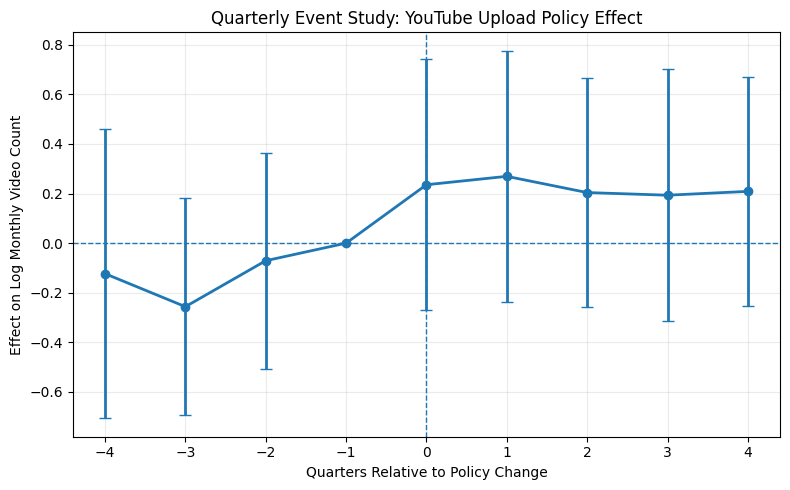

In [32]:
# 11. Plot
plt.figure(figsize=(8, 5))

plt.errorbar(
    event_plot["event_time_q"],
    event_plot["coef"],
    yerr=[
        event_plot["coef"] - event_plot["ci_low"],
        event_plot["ci_high"] - event_plot["coef"]
    ],
    fmt="o-",
    capsize=4,
    linewidth=2,
    markersize=6
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Quarters Relative to Policy Change")
plt.ylabel("Effect on Log Monthly Video Count")
plt.title("Quarterly Event Study: YouTube Upload Policy Effect")

plt.xticks(range(-4, 5))
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("/content/quarterly_event_study.png", dpi=300, bbox_inches="tight")
plt.show()

DID Results: Posting Frequency, Likes, and Comments

In [22]:
# post frequency
model1 = smf.ols(
    "log_videos ~ did + C(creator_id) + C(month_date)",
    data=df
).fit()

# likes
model2 = smf.ols(
    "log_likes ~ did + C(creator_id) + C(month_date)",
    data=df
).fit()

# comments
model3 = smf.ols(
    "log_comments ~ did + C(creator_id) + C(month_date)",
    data=df
).fit()

print(model1.summary())
print(model2.summary())
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             log_videos   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     36.03
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.48e-96
Time:                        04:10:16   Log-Likelihood:                -82.543
No. Observations:                 351   AIC:                             255.1
Df Residuals:                     306   BIC:                             428.8
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

Parallel Trends Check for Treated vs Control Creators

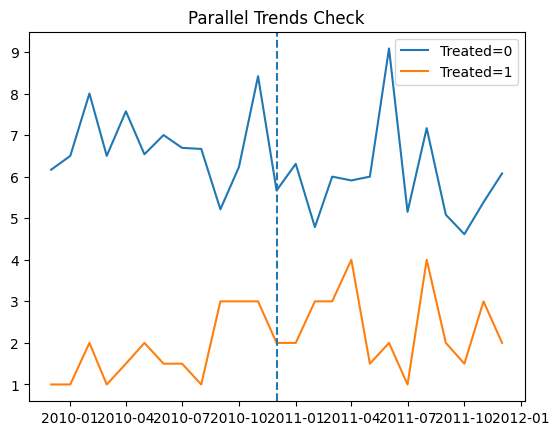

In [33]:
import matplotlib.pyplot as plt

avg = df.groupby(["month_date","treated_creator"])["monthly_video_count"].mean().reset_index()

for k, g in avg.groupby("treated_creator"):
    plt.plot(g["month_date"], g["monthly_video_count"], label=f"Treated={k}")

plt.axvline(pd.Timestamp("2010-12-01"), linestyle="--")
plt.legend()
plt.title("Parallel Trends Check")
plt.show()